In [10]:
import common_imports
from common_imports import *


In [11]:
# LFW: http://vis-www.cs.umass.edu/lfw/  (download + extract if missing)
import shutil
import ssl
import tarfile
import urllib.error
import urllib.request
import certifi

LFW_TGZ = "lfw.tgz"
LFW_ROOT = "lfw"
# HTTPS mirror first (often more reachable); then UMass HTTP.
LFW_URLS = (
    "https://ndownloader.figshare.com/files/5976018",
    "http://vis-www.cs.umass.edu/lfw/lfw.tgz",
)


def _download_url(url: str, dest: str, ssl_context: ssl.SSLContext | None) -> None:
    if url.lower().startswith("https"):
        opener = urllib.request.build_opener(
            urllib.request.HTTPSHandler(context=ssl_context)
        )
    else:
        opener = urllib.request.build_opener()
    with opener.open(url, timeout=300) as resp:
        with open(dest, "wb") as out:
            shutil.copyfileobj(resp, out)


if not os.path.isfile(LFW_TGZ):
    last_err: BaseException | None = None
    for url in LFW_URLS:
        try:
            print(f"Downloading {url} ...")
            if url.lower().startswith("https"):
                try:
                    ctx = ssl.create_default_context(cafile=certifi.where())
                    _download_url(url, LFW_TGZ, ctx)
                except (urllib.error.URLError, ssl.SSLError) as e:
                    err_s = str(e).lower()
                    if "certificate" in err_s or "ssl" in err_s:
                        print(
                            "  SSL verify failed with certifi; retrying without verify (less secure)."
                        )
                        _download_url(url, LFW_TGZ, ssl._create_unverified_context())
                    else:
                        raise
            else:
                _download_url(url, LFW_TGZ, None)
            break
        except (urllib.error.URLError, OSError) as e:
            last_err = e
            print(f"  failed: {e}")
    else:
        raise RuntimeError(
            "Could not download LFW. Install certs (macOS: run 'Install Certificates.command' "
            "for your Python), or place lfw.tgz next to this notebook."
        ) from last_err



In [12]:
if not os.path.isdir(LFW_ROOT):
    print("Extracting LFW ...")
    with tarfile.open(LFW_TGZ, "r:gz") as tar:
        try:
            tar.extractall(filter="data")
        except TypeError:
            tar.extractall()

if not os.path.isdir(LFW_ROOT):
    raise FileNotFoundError(
        f"Expected folder {LFW_ROOT!r} after extract. cwd={os.getcwd()}"
    )

# Move LFW images into data/negative (flat folder)
for directory in os.listdir(LFW_ROOT):
    folder = os.path.join(LFW_ROOT, directory)
    if not os.path.isdir(folder):
        continue
    for file in os.listdir(folder):
        if not file.lower().endswith((".jpg", ".jpeg")):
            continue
        ex_path = os.path.join(folder, file)
        new_path = os.path.join(NEG_PATH, file)
        os.replace(ex_path, new_path)


Extracting LFW ...


In [13]:
# --- Crop settings (frame center) ---
ROI = 250  # preview square size (larger is easier for framing)
# Saved anchor/positive: same size as the first step of preprocess() in 3.ipynb (cv2.resize → 100×100).
MODEL_INPUT_SIZE = (100, 100)
# Nudge crop origin in pixels (+ right / + down)
OFFSET_X = 0
OFFSET_Y = 0
# True = horizontal flip (selfie-style); set False if left/right feels wrong
MIRROR_HORIZONTAL = True

# Last ROI frame — shown in matplotlib in the next cell
last_frame = None


def training_jpeg_from_roi(roi_bgr):
    """BGR jak z kamery → BGR 100×100 jak w `preprocess` w 3.ipynb przed BGR→RGB."""
    return cv2.resize(roi_bgr, MODEL_INPUT_SIZE)


def center_square_roi(frame_bgr, side: int, off_x: int = 0, off_y: int = 0):
    """Square crop from the frame center; if the frame is smaller than `side`, resize to `side`."""
    h, w = frame_bgr.shape[:2]
    if h >= side and w >= side:
        x0 = (w - side) // 2 + off_x
        y0 = (h - side) // 2 + off_y
        x0 = max(0, min(x0, w - side))
        y0 = max(0, min(y0, h - side))
        return frame_bgr[y0 : y0 + side, x0 : x0 + side, :]
    s = min(h, w)
    y0 = (h - s) // 2
    x0 = (w - s) // 2
    patch = frame_bgr[y0 : y0 + s, x0 : x0 + s, :]
    return cv2.resize(patch, (side, side))


# Try camera indices until one returns frames
cap = None
for cam_index in (0, 1, 2, 3, 4):
    c = cv2.VideoCapture(cam_index)
    if c.isOpened():
        ret, test = c.read()
        if ret and test is not None and test.size > 0:
            cap = c
            print(f"Camera: index {cam_index}")
            break
        c.release()

if cap is None or not cap.isOpened():
    print(
        "Could not open the camera. Check System Settings → Privacy → Camera "
        "and the device. Edit cam_index in this cell if you use another camera."
    )
else:
    print(
        "Controls:  a  = save anchor → data/anchor,  "
        "p  = save positive → data/positive,  q  = quit.\n"
        "Center your face; adjust OFFSET_X / OFFSET_Y if needed."
    )
    for _ in range(30):
        cap.read()

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret or frame is None:
                cv2.waitKey(5)
                continue

            if MIRROR_HORIZONTAL:
                frame = cv2.flip(frame, 1)

            roi = center_square_roi(frame, ROI, OFFSET_X, OFFSET_Y)
            last_frame = roi.copy()

            cv2.imshow("Image Collection", roi)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("a"):
                imgname = os.path.join(ANC_PATH, "{}.jpg".format(uuid.uuid1()))
                cv2.imwrite(imgname, training_jpeg_from_roi(roi))
                print(f"saved anchor (100×100 as in 3.ipynb): {imgname}")
            elif key == ord("p"):
                imgname = os.path.join(POS_PATH, "{}.jpg".format(uuid.uuid1()))
                cv2.imwrite(imgname, training_jpeg_from_roi(roi))
                print(f"saved positive (100×100 as in 3.ipynb): {imgname}")
            elif key == ord("q"):
                break
    finally:
        cap.release()
cv2.destroyAllWindows()


Camera: index 0
Controls:  a  = save anchor → data/anchor,  p  = save positive → data/positive,  q  = quit.
Center your face; adjust OFFSET_X / OFFSET_Y if needed.
saved positive (100×100 as in 3.ipynb): /Users/igorhebda/Desktop/HTW-Bio/Part_2/data/positive/1f3b9482-35c0-11f1-a9c0-9ab6d786755e.jpg
saved positive (100×100 as in 3.ipynb): /Users/igorhebda/Desktop/HTW-Bio/Part_2/data/positive/1fa1833c-35c0-11f1-a9c0-9ab6d786755e.jpg
saved positive (100×100 as in 3.ipynb): /Users/igorhebda/Desktop/HTW-Bio/Part_2/data/positive/1ffc2f80-35c0-11f1-a9c0-9ab6d786755e.jpg
saved positive (100×100 as in 3.ipynb): /Users/igorhebda/Desktop/HTW-Bio/Part_2/data/positive/2049934c-35c0-11f1-a9c0-9ab6d786755e.jpg
saved positive (100×100 as in 3.ipynb): /Users/igorhebda/Desktop/HTW-Bio/Part_2/data/positive/208b4012-35c0-11f1-a9c0-9ab6d786755e.jpg
saved positive (100×100 as in 3.ipynb): /Users/igorhebda/Desktop/HTW-Bio/Part_2/data/positive/20d2653c-35c0-11f1-a9c0-9ab6d786755e.jpg
saved positive (100×100 as

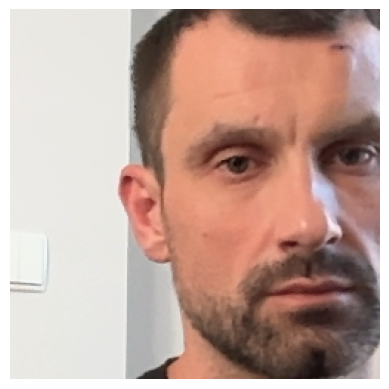

In [14]:
# Needs the camera cell — `last_frame` is the ROI preview (e.g. 250×250); files on disk are 100×100 like 3.ipynb.
# OpenCV uses BGR; matplotlib expects RGB.
from common_imports import *

_f = globals().get("last_frame")
if _f is None:
    print(
        "No last frame: run the camera cell first (preview must open), "
        "or the camera returned no image — check the previous cell output."
    )
else:
    plt.imshow(cv2.cvtColor(_f, cv2.COLOR_BGR2RGB))
    plt.axis("off")


In [15]:
def data_aug(img_bgr):
    """Nine random augmentations (BGR uint8): brightness/contrast/flip in PyTorch, rest in OpenCV."""
    if img_bgr is None:
        raise ValueError("img_bgr is None — cv2.imread failed?")

    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    base = torch.from_numpy(rgb).permute(2, 0, 1).contiguous().float() / 255.0
    data = []

    for _ in range(9):
        y = base.clone()
        # brightness (~ tf.image.random_brightness, max_delta=0.02 in [0,1])
        delta = (torch.rand(1) * 2 - 1) * 0.02
        y = torch.clamp(y + delta.view(1, 1, 1), 0, 1)
        # contrast (~ tf.image.random_contrast, lower=0.6, upper=1.0)
        alpha = torch.empty(1).uniform_(0.6, 1.0)
        mean = y.mean(dim=(1, 2), keepdim=True)
        y = torch.clamp((y - mean) * alpha.view(1, 1, 1) + mean, 0, 1)
        # horizontal flip
        if torch.rand(()) < 0.5:
            y = torch.flip(y, dims=(-1,))

        rgb_u8 = (y * 255).to(torch.uint8).permute(1, 2, 0).cpu().numpy()
        x = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2BGR)

        q = int(torch.randint(90, 101, (1,)).item())
        ok, enc = cv2.imencode(".jpg", x, [int(cv2.IMWRITE_JPEG_QUALITY), q])
        if ok:
            x = cv2.imdecode(enc, cv2.IMREAD_COLOR)

        hsv = cv2.cvtColor(x, cv2.COLOR_BGR2HSV).astype(np.float32)
        s_scale = float(torch.empty(1).uniform_(0.9, 1.0))
        hsv[:, :, 1] = np.clip(hsv[:, :, 1] * s_scale, 0, 255)
        x = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

        data.append(x)

    return data


In [16]:
# First .jpg in data/anchor (avoid hard-coded tutorial filenames — yours may be UUIDs)
names = sorted(
    n for n in os.listdir(ANC_PATH) if n.lower().endswith((".jpg", ".jpeg"))
)
if not names:
    raise FileNotFoundError(
        f"No .jpg in {ANC_PATH!r}. Run the camera cell and save a few images (key a)."
    )
img_path = os.path.join(ANC_PATH, names[0])
print("Augmentation source:", img_path)

img = cv2.imread(img_path)
augmented_images = data_aug(img)

for image in augmented_images:
    cv2.imwrite(os.path.join(ANC_PATH, "{}.jpg".format(uuid.uuid1())), image)


Augmentation source: /Users/igorhebda/Desktop/HTW-Bio/Part_2/data/anchor/25a1ab9a-35c0-11f1-a9c0-9ab6d786755e.jpg


In [17]:
for file_name in os.listdir(POS_PATH):
    if not file_name.lower().endswith((".jpg", ".jpeg")):
        continue
    img_path = os.path.join(POS_PATH, file_name)
    img = cv2.imread(img_path)
    if img is None:
        continue
    augmented_images = data_aug(img)

    for image in augmented_images:
        cv2.imwrite(os.path.join(POS_PATH, "{}.jpg".format(uuid.uuid1())), image)
